# World Models 2018

这里，我们将复现经典论文：[World Models](https://arxiv.org/abs/1803.10122)。模型结构较为清晰，只需理解 Vision (V), Memory (M), 和 Controller (C) 这三个模块，整个模型就差不多就可以算作是理解了。

<small> 注意：该文仍存在某些问题，训练出的 CarRacing Agent 不尽人意。但具体原因没有找到，可能是数据采集太少，也可能训练时长不够。 </small>

简单说一下整体架构。Vision 部分由 VAE 实现，负责将观测图像压缩到隐空间；Memory 部分由 MDN-RNN 实现，是整个世界模型的动力学模型（dynamic model），负责模拟隐空间中状态量的变化；Controller 是个简单的 MLP，负责根据当前 Memory 状态与当前 Vision 数据进行动作决策。我们预期在实现基本框架后在 `CarRacing` 上面跑一跑，不涉及 `VizDoom` 相关实验。

## 1. 基本模块代码实现

这部分，我们分别实现 V, M, C 三个组件的代码。

### 1.1 Vision (VAE)

先来导入一些基本的库：

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

下面是 Encoder。作者将 `64 * 64 * 3` 的输入经过四层卷积，转化为了 `2 * 2 * 256` 的数据，然后用一个线性层映射到 $\mu$ 和 $\sigma$. 每个卷积层中卷积核 `size` 均为 `4`，步长为 `2`. 

注意，`Conv2d` 要求输入符合 $(B,C,H,W)$，如果输入 `X` 不是这个样子的（比如 $(B, H, W, C)$），需要额外进行一步操作（比如 `X = X.permute(0, 3, 1, 2)`）.

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=0), # -> (32, 31, 31)
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=0), # -> (64, 14, 14)
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=0), # -> (128, 6, 6)
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=0), # -> (256, 2, 2)
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)

    def forward(self, X):
        # X: (batch_size, 3, 64, 64)
        X = self.conv_layer(X)
        X_flatten = X.flatten(start_dim=1)

        mu = self.fc_mu(X_flatten)
        logvar = self.fc_logvar(X_flatten)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

紧接着是 Decoder，如下：

In [3]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        
        self.fc = nn.Linear(latent_dim, 1024 * 1 * 1) # z -> 1024 * 1 * 1 
        
        self.deconv_layers = nn.Sequential(
            # (1024, 1, 1) -> (128, 5, 5)
            nn.ConvTranspose2d(1024, 128, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),

            # (128, 5, 5) -> (64, 13, 13)
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),

            # (64, 13, 13) -> (32, 30, 30)
            nn.ConvTranspose2d(64, 32, kernel_size=6, stride=2, padding=0),
            nn.ReLU(),

            # (32, 30, 30) -> (3, 64, 64)
            nn.ConvTranspose2d(32, 3, kernel_size=6, stride=2, padding=0),
            nn.Sigmoid()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 1024, 1, 1)
        x = self.deconv_layers(x)
        return x

下面进行一个简单的测试，以确保 `Encoder` 和 `Decoder` 的参数配置及张量维度均无误。

In [4]:
enc = Encoder()
dec = Decoder()

test_X = torch.randn(8, 3, 64, 64)

test_mu, test_logvar = enc(test_X)
test_z = enc.reparameterize(test_mu, test_logvar)
test_X_recon = dec(test_z)

print(f"Shape of test_z: {test_z.shape}")
print(f"Shape of reconstructed X: {test_X_recon.shape}")

Shape of test_z: torch.Size([8, 32])
Shape of reconstructed X: torch.Size([8, 3, 64, 64])


看来张量维度没有问题，VAE 这部分也就基本实现了，我们下面先搞个简单的，即 `Controller`，最后再来搞 `Memory` 部分。

### 1.2 Controller

`Controller` 接收来自 `Memory` 的隐藏向量 `h` 和 `Vision` 的潜在表示 `z` 作为输入，（在 `CarRacing` 中），输出油门力度 $[0,1]$，刹车力度 $[0,1]$，以及方向盘 $[-1,1]$。

没有隐藏层，整体就是一个线性的映射。不过我们需要还需要分别施加适当的激活函数，将输出限制在对应范围内。

In [5]:
class Controller(nn.Module):
    def __init__(self, z_dim=32, hidden_dim=256, action_dim=3):
        super().__init__()
        self.fc = nn.Linear(z_dim + hidden_dim, action_dim)

    def forward(self, z, h):
        cat_in = torch.cat([z, h], dim=1)

        # actions[0] for steer wheel, [1] for pedal, [2] for brake
        raw_actions = self.fc(cat_in)

        steer = torch.tanh(raw_actions[:, 0:1])
        gas = torch.sigmoid(raw_actions[:, 1:2])
        brake = torch.sigmoid(raw_actions[:, 2:3])
        actions = torch.cat([steer, gas, brake], dim=1)

        return actions

再次进行一个小测试：

In [6]:
controller = Controller()
test_z = torch.randn(8, 32)
test_h = torch.randn(8, 256)
actions = controller(test_z, test_h)
print(f"Shape of actions: {actions.shape}")
print(f"steer: {actions[0][0]}, pedal: {actions[0][1]}, brake: {actions[0][2]}")

Shape of actions: torch.Size([8, 3])
steer: -0.5172522664070129, pedal: 0.6449698209762573, brake: 0.7479562759399414


### 1.3 Memory

`Memory` 的整体架构是 MDN-RNN，RNN 由 LSTM 具体实现。整个架构如下图所示。

![mdn-rnn-arch](assets/mdn-rnn-arch.svg)

这里简单说明一下 MDN-RNN，其与正常的 RNN 基本相同，只是在输出层上，RNN 输出一个具体的向量，而 MDN-RNN 输出几组 $(\pi, \mu, \sigma)$，其中，$\pi$ 为当前分布的权重，$\mu$ 和 $\sigma$ 则表示一个概率分布。论文中，取组数 $K = 5$。得到 $\{(\pi, \mu, \sigma)\}$ 后，通过下面代码中的方法取样，并重构 $z'$。

In [7]:
import math
import numpy as np

In [8]:
class MDNRNN(nn.Module):
    def __init__(self, z_dim=32, hidden_dim=256, action_dim=3, num_gaussians=5, tau=1.0):
        """
        MDN-RNN
        """
        super().__init__()
        self.z_dim = z_dim
        self.hidden_dim = hidden_dim
        self.num_gaussians = num_gaussians
        self.tau = 1.0
        
        self.lstm = nn.LSTM(
            input_size=z_dim + action_dim, 
            hidden_size=hidden_dim, 
            num_layers=1, 
            batch_first=True
        )
        
        # predict pi, mu and sigma
        self.fc_pi = nn.Linear(hidden_dim, num_gaussians)
        self.fc_mu = nn.Linear(hidden_dim, num_gaussians * z_dim)
        self.fc_sigma = nn.Linear(hidden_dim, num_gaussians * z_dim)

    def forward(self, z_seq, action_seq, hidden=None):
        B, T, _ = z_seq.shape
        
        lstm_input = torch.cat([z_seq, action_seq], dim=-1) # (B, T, 32 + 3)
        
        output, hidden = self.lstm(lstm_input, hidden)     # (B, T, 256)
        
        pi_logits = self.fc_pi(output)                     # (B, T, K)
        pi = F.softmax(pi_logits / self.tau, dim=-1)
        
        mu = self.fc_mu(output).reshape(B, T, self.num_gaussians, self.z_dim) # (B, T, K, 32)
        
        sigma = self.fc_sigma(output).reshape(B, T, self.num_gaussians, self.z_dim) # (B, T, K, 32)
        sigma = torch.exp(sigma) # ensure sigma > 0
        
        return pi, mu, sigma, hidden

    def sample_mdn(self, pi, mu, sigma):

        k = torch.distributions.Categorical(probs=pi).sample() # (B, T)
    
        k = k[..., None, None] # (B, T, 1, 1)
        k = k.expand(-1, -1, 1, mu.size(-1)) # (B, T, 1, D)
    
        selected_mu = torch.gather(mu, dim=2, index=k).squeeze(2) # (B, T, D)
        selected_sigma = torch.gather(sigma, dim=2, index=k).squeeze(2) # (B, T, D)
    
        eps = torch.randn_like(selected_mu)
        z_recon = selected_mu + selected_sigma * math.sqrt(self.tau) * eps
    
        return z_recon

In [9]:
B = 8
T = 8
z_seq = torch.randn(B, T, 32)
actions = torch.randn(B, T, 3)

mdn_rnn = MDNRNN()

pi, mu, sigma, hidden = mdn_rnn(z_seq, actions)

print(f"pi: {pi.shape}")
print(f"mu: {mu.shape}")
print(f"sigma: {sigma.shape}")
print(f"hidden state 0: {hidden[0].shape}")
print(f"hidden state 1: {hidden[1].shape}")

z_recon = mdn_rnn.sample_mdn(pi, mu, sigma)
print(f"z_recon shape: {z_recon.shape}")

pi: torch.Size([8, 8, 5])
mu: torch.Size([8, 8, 5, 32])
sigma: torch.Size([8, 8, 5, 32])
hidden state 0: torch.Size([1, 8, 256])
hidden state 1: torch.Size([1, 8, 256])
z_recon shape: torch.Size([8, 8, 32])


另外，我注意到，官方的 `mdn-rnn` 实现中直接使用一个线性头将 `hidden state` 映射到 `[pi, mu, sigma]` 一整个向量中，而不是像我这样搞成三个线性头。官方实现具有更优的效率，但我还是保留我最开始的做法。

接下来开始真实环境的训练了。

---

## 2. 环境准备与数据收集

首先，我们需要安装一些基本环境。另外，由于原来的 `CarRacing-v0` 版本过低，此处采用 `CarRacing-v3` 作为环境。

In [ ]:
!pip install "gymnasium[box2d]"
!pip install cma

安装完成后，开始准备环境并写一个数据收集脚本。

In [11]:
import gymnasium as gym

env = gym.make("CarRacing-v3", continuous=True)

按照 `gymnasium` 的标准流程，我们模拟汽车运动，使用随机策略，然后不断收集运动中的 `observations`, `actions` 数据，如下：

In [12]:
def collect_episode(env, max_steps=1000):
    obs, _ = env.reset()
    observations = [obs]
    actions = []
    rewards = []

    for t in range(max_steps):
        action = env.action_space.sample()

        next_obs, reward, terminated, truncated, _ = env.step(action)

        actions.append(action)
        rewards.append(reward)
        observations.append(next_obs)

        obs = next_obs

        if terminated or truncated:
            break

    return (
        np.asarray(observations, dtype=np.uint8),
        np.asarray(actions, dtype=np.float32),
        np.asarray(rewards, dtype=np.float32),
    )

In [13]:
observations, actions, rewards = collect_episode(env)

In [14]:
print(observations.shape, actions.shape, rewards.shape)

(1001, 96, 96, 3) (1000, 3) (1000,)


这里使用小规模的数据用于测试，官方一共跑了 `10000 episodes`，我们这里只收集了一个 episode 的数据。后续训练 VAE 的时候可能会考虑多跑点。

---

## 3. Vision 部分的训练

注意到，原始的输入是 $96\times 96 \times 3$ 的图像，我们需要转化后才可以输入到 VAE 中，具体流程如下：

$$
96\times96\times3
\rightarrow
3\times 64\times64
\rightarrow
VAE
\rightarrow
z\in\mathbb R^{32}.
$$

故而搞一个数据放缩函数：

In [15]:
def preprocess_obs(obs):
    # obs: (batch_size, 96, 96, 3)

    x = obs.float() / 255.0
    x = x.permute(0, 3, 1, 2)       # (batch_size, 3, 96, 96)

    x = F.interpolate(
        x,
        size=(64, 64),
        mode="bilinear",
        align_corners=False
    )

    return x

我们跑 10 个 epsisode 收集数据

In [16]:
observation_list = []
for _ in range(10):
    obs, _, _ = collect_episode(env)
    observation_list.append(torch.from_numpy(obs))
observations = torch.cat(observation_list, dim=0)

In [17]:
observations = preprocess_obs(observations)
print(observations.shape)

torch.Size([10010, 3, 64, 64])


接下来构造数据集

In [18]:
from torch.utils.data import Dataset, DataLoader

In [19]:
class ImageDataset(Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


dataset = ImageDataset(observations)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

然后开始定义模型，并进行训练循环

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)

epochs = 50

for epoch in range(epochs):
    encoder.train()
    decoder.train()

    total_loss, total_recon, total_kl = 0, 0, 0
        
    for x in dataloader:
        x = x.to(device) # (batch_size, 3, 64, 64)
            
        optimizer.zero_grad()
            
        mu, logvar = encoder(x)
        z = encoder.reparameterize(mu, logvar)
        recon_x = decoder(z)

        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
            
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss / len(dataloader):.6f} | Recon Loss: {total_recon / (len(dataloader)):.6f} | KL Loss: {total_kl / (len(dataloader)):.6f}")

Using device: cuda
Epoch [1/50] Loss: 482599.584395 | Recon Loss: 481154.238654 | KL Loss: 1445.346237
Epoch [2/50] Loss: 443435.611166 | Recon Loss: 442258.594148 | KL Loss: 1177.018560
Epoch [3/50] Loss: 439019.369327 | Recon Loss: 437838.802249 | KL Loss: 1180.567262
Epoch [4/50] Loss: 435840.139431 | Recon Loss: 434603.165307 | KL Loss: 1236.973293
Epoch [5/50] Loss: 434525.998408 | Recon Loss: 433374.503782 | KL Loss: 1151.494823
Epoch [6/50] Loss: 433851.858380 | Recon Loss: 432794.187102 | KL Loss: 1057.670840
Epoch [7/50] Loss: 433416.279260 | Recon Loss: 432433.798865 | KL Loss: 982.480741
Epoch [8/50] Loss: 433061.260748 | Recon Loss: 432137.651672 | KL Loss: 923.609709
Epoch [9/50] Loss: 432768.826732 | Recon Loss: 431888.200239 | KL Loss: 880.627263
Epoch [10/50] Loss: 432531.067476 | Recon Loss: 431680.342755 | KL Loss: 850.725249
Epoch [11/50] Loss: 432331.845840 | Recon Loss: 431516.675259 | KL Loss: 815.170440
Epoch [12/50] Loss: 432165.167894 | Recon Loss: 431373.34663

象征性地训练几下，然后看看重建效果（ChatGPT 写的可视化代码，自己拿来改了改）：

In [21]:
import matplotlib.pyplot as plt

In [22]:
def visualize_reconstruction(
    encoder,
    decoder,
    dataloader,
    device,
    num_images=8
):

    encoder.eval()
    decoder.eval()

    x = next(iter(dataloader))
    x = x.to(device)

    with torch.no_grad():
        mu, logvar = encoder(x)
        z = mu
        recon_x = decoder(z)

    x = x.cpu()
    recon_x = recon_x.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(16,4))

    for i in range(num_images):
        # original
        img = x[i].permute(1,2,0)

        axes[0,i].imshow(img)
        axes[0,i].axis("off")
        axes[0,i].set_title("Original")

        # reconstruction
        img = recon_x[i].permute(1,2,0)

        # 防止 decoder 输出略微越界
        img = torch.clamp(img, 0, 1)

        axes[1,i].imshow(img)
        axes[1,i].axis("off")
        axes[1,i].set_title("Recon")

    plt.tight_layout()
    plt.show()

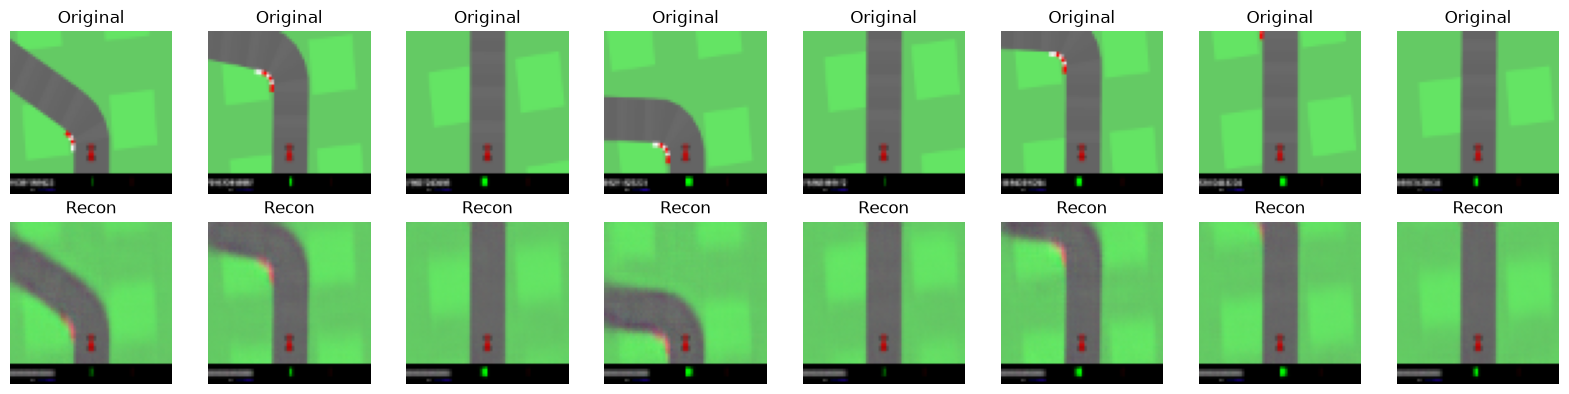

In [23]:
visualize_reconstruction(encoder, decoder, dataloader, device)

经过多次试验后终于得到了比较理想的重构效果。

具体原因分析放在之后吧，现在只记录几个实现方法的区别：
1. MSE 重构误差，KL_Loss 除以 `batch_size`，效果很差，对于任意输入都只输出平均画面；
2. MSE 重构误差，调整 KL_Loss 占比（由 1 变成 0.1, 0.01, 0.001, 0.003），效果都不好；
3. $L^2$ 误差，KL_Loss 不再除以 `batch_size` 

***
## 4. Memory 部分训练

首先跑 10 个 episode 收集数据（之前没有收集 `action` 信息）。

这里，由于我们训练的东西存在一个时间维度，因此不能首尾拼接在一起。我们将图像观测保留成 $10 \times 1000 \times 96 \times 96 \times 3$ 的样子，并紧接着转化成 $10 \times 1000 \times 3 \times 64 \times 64$ 的样子。

In [34]:
obs_seqs = []
action_seqs = []
for _ in range(10):
    obs, actions, _ = collect_episode(env)
    obs_seqs.append(torch.from_numpy(obs))
    action_seqs.append(torch.from_numpy(actions).float())
obs_seqs = torch.stack(obs_seqs, dim=0).to(device)
action_seqs = torch.stack(action_seqs, dim=0).to(device)

print(obs_seqs.shape, action_seqs.shape)

torch.Size([10, 1001, 96, 96, 3]) torch.Size([10, 1000, 3])


In [38]:
E, T, C, H, W = obs_seqs.shape
obs_flattened = obs_seqs.reshape(E * T, C, H, W)
obs_scaled = preprocess_obs(obs_flattened)

with torch.no_grad():
    mu, logvar = encoder(obs_scaled)
    z_flattened = encoder.reparameterize(mu, logvar)

z_seqs = z_flattened.reshape(E, T, -1)

print(z_flattened.shape, z_seqs.shape)

torch.Size([10010, 32]) torch.Size([10, 1001, 32])


上面，我们得到了观测与动作数据后，紧接着用刚刚训练好的 `decoder` 将所有观测全部转化成潜在空间的向量形式，之后整个 mdn-rnn 模型都是在潜在空间中进行训练的，与观测空间无关。

补充说明一下，这里和官方实现有一些出入。官方是先保留 $z$ 的原始 $\sigma, \mu$ 的，而我们这里直接把 $z$ 固定了。这里我保留我最原始的实现想法。

接下来，我们定义针对 mdn-rnn 训练的数据集，并处理好数据方便训练。

In [39]:
class RNNTrajectoryDataset(Dataset):
    def __init__(self, z_seqs, action_seqs):
        self.z_seqs = z_seqs
        self.action_seqs = action_seqs
        
    def __len__(self):
        return len(self.z_seqs)
    
    def __getitem__(self, idx):
        z = self.z_seqs[idx] # (T+1, dim_z)
        actions = self.action_seqs[idx] # (T, dim_action)
        
        inputs_z = z[:-1] # z_0 ... z_{T-1}
        targets_z = z[1:] # z_1 ... z_T
        
        return inputs_z, actions, targets_z

In [40]:
dataset = RNNTrajectoryDataset(z_seqs, action_seqs)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

数据准备就绪！然后我们去定义损失函数。这个搞完后，就可以开始正式的训练循环了。

In [50]:
def mdn_loss_fn(pi, mu, sigma, target):
    # (B, T, Z) -> (B, T, 1, Z)
    target = target.unsqueeze(2) 

    dist = torch.distributions.Normal(mu, sigma)

    # (B, T, K, Z) -> (B, T, K)
    log_probs = dist.log_prob(target).sum(dim=-1)
    log_pi = torch.log(pi + 1e-8)

    # (B, T, K) -> (B, T)
    log_likelihood = torch.logsumexp(log_pi + log_probs, dim=-1)
    return -log_likelihood.mean()

上面损失函数可以用这个公式表示：

$$
\mathcal L
=
-\frac{1}{BT}
\sum_{b=1}^{B}
\sum_{t=1}^{T}
\log
\left[
\sum_{k=1}^{K}
\pi_{b,t,k}
\prod_{j=1}^{Z}
\mathcal N
\left(
y_{b,t,j};
\mu_{b,t,k,j},
\sigma_{b,t,k,j}
\right)
\right]
$$

其中，

$$
\mathcal N
\left(
t;
\mu,\sigma
\right)
=
\frac{1}{\sqrt{2\pi}\sigma}
\exp
\left(
-\frac{(y-\mu)^2}{2\sigma^2}
\right)
$$

这个表示潜在空间的目标向量 $t$(`target`) 在分布 $\mathcal{N}(\mu, \sigma)$ 下的概率密度值。放到整个公式中，我们按 $\pi$ 加权。

同时，我们通过求 $\log$ 以求避免概率值的精度问题。

In [51]:
mdn_rnn = MDNRNN().to(device)

In [52]:
optimizer = torch.optim.Adam(
    mdn_rnn.parameters(),
    lr=1e-3
)

epochs = 50
for epoch in range(epochs):
    mdn_rnn.train()
    total_loss = 0.0

    for z, actions, targets in loader:
        z = z.to(device)
        actions = actions.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        pi, mu, sigma, _ = mdn_rnn(z, actions)
        loss = mdn_loss_fn(pi, mu, sigma, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdn_rnn.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}: loss = {total_loss / len(loader):.6f}")

Epoch 1/50: loss = 45.180227
Epoch 2/50: loss = 44.829142
Epoch 3/50: loss = 44.651110
Epoch 4/50: loss = 44.235439
Epoch 5/50: loss = 43.765375
Epoch 6/50: loss = 43.023652
Epoch 7/50: loss = 42.329803
Epoch 8/50: loss = 41.837939
Epoch 9/50: loss = 41.239376
Epoch 10/50: loss = 40.667461
Epoch 11/50: loss = 40.121777
Epoch 12/50: loss = 39.511058
Epoch 13/50: loss = 39.301067
Epoch 14/50: loss = 38.826124
Epoch 15/50: loss = 38.499892
Epoch 16/50: loss = 38.354214
Epoch 17/50: loss = 38.031417
Epoch 18/50: loss = 37.842047
Epoch 19/50: loss = 37.638954
Epoch 20/50: loss = 37.440093
Epoch 21/50: loss = 37.216942
Epoch 22/50: loss = 37.165904
Epoch 23/50: loss = 37.023207
Epoch 24/50: loss = 36.842500
Epoch 25/50: loss = 36.884773
Epoch 26/50: loss = 36.698853
Epoch 27/50: loss = 36.969546
Epoch 28/50: loss = 36.715846
Epoch 29/50: loss = 36.513934
Epoch 30/50: loss = 36.394835
Epoch 31/50: loss = 36.300074
Epoch 32/50: loss = 36.419230
Epoch 33/50: loss = 36.211313
Epoch 34/50: loss =

上面 `clip_grad_norm_` 用于进行梯度的缩放，防止梯度爆炸。

训练了 `50` 个 `epoch`，仍未见收敛之势。我们也没有直观验证的方法，就先把 `Controller` 部分继续训练完吧。

***
## 5. Controller 训练

这里使用的是 CMA-ES 策略。我们这里不去讲原理，而是基于已经实现好的库进行代码操作。`cma` 不进行反向传播与梯度下降，而是直接优化模型参数。在我们的 `Controller` 中，其参数量为 $$ 3(32+256)+3=867 $$，故 CMA-ES 直接优化 $\theta \in \mathbb{R}^{867}$.



具体实现上，我们首先得实现两个函数。一个将 Controller 的参数提取成一个向量，另一个将参数向量装回 Controller. 代码如下（用 AI 写的）：

In [54]:
def get_controller_params(controller):
    return torch.cat([p.detach().flatten() for p in controller.parameters()])

def set_controller_params(controller, theta):
    offset = 0

    with torch.no_grad():
        for p in controller.parameters():
            n = p.numel()
            p.copy_(theta[offset:offset+n].view_as(p))
            offset += n

然后我们去实现一个评估函数，其将评估当前参数下模型的表现。根据这个评估结果，CMA-ES 演化算法会从几个参数候选项中择优进行下一轮演化。

In [68]:
def evaluate_controller(controller, encoder, mdn_rnn, env, device):
    obs, _ = env.reset()
    hidden = None
    total_reward = 0.0
    done = False

    while not done:
        # preprocess observation
        obs_tensor = torch.from_numpy(obs).unsqueeze(0)
        obs_tensor = preprocess_obs(obs_tensor).to(device)

        with torch.no_grad():
            mu, logvar = encoder(obs_tensor)
            z = encoder.reparameterize(mu, logvar)
            
            # initialize hidden state
            if hidden is None:
                h = torch.zeros(1, mdn_rnn.hidden_dim, device=device)
            else:
                h = hidden[0][-1]

            # Controller: (z_t, h_t) -> a_t
            action = controller(z, h)

            # update RNN hidden
            _, _, _, hidden = mdn_rnn(z.unsqueeze(1), action.unsqueeze(1), hidden)

        action_np = (action.squeeze(0).cpu().numpy())
        obs, reward, terminated, truncated, _ = env.step(action_np)

        total_reward += reward
        done = terminated or truncated

    return total_reward

接下来，就开始正式的 CMA 策略训练了：

In [69]:
import cma

In [70]:
controller = Controller().to(device)

In [ ]:
theta0 = (get_controller_params(controller).cpu().numpy())
es = cma.CMAEvolutionStrategy(theta0, 0.1)

generation = 0
while not es.stop() and generation < 50:
    solutions = es.ask()
    fitnesses = []

    for theta in solutions:
        theta_tensor = torch.tensor(theta, dtype=torch.float32, device=device)
        set_controller_params(controller, theta_tensor)
        reward = evaluate_controller(controller, encoder, mdn_rnn, env, device)
        fitnesses.append(-reward)

    es.tell(solutions, fitnesses)
    es.disp()
    generation += 1

注意到，上述代码中，我们时常把数据移到 cpu，又转换为了 `numpy` 数组。这是由于 CMA-ES 策略使用 `Numpy`，因而需要来回转换。

另外，其实并行化应该会更快，但考虑到需要多核的协调，代码量也上去了，懒得搞了。就这样吧。

In [75]:
best_theta = es.result.xbest
best_theta_tensor = torch.tensor(best_theta, dtype=torch.float32, device=device)
set_controller_params(controller, best_theta_tensor)
rewards = [evaluate_controller(controller, encoder, mdn_rnn, env, device) for _ in range(5)]

print("mean reward:", np.mean(rewards))
print("std reward:", np.std(rewards))

mean reward: -10.230955312158297
std reward: 19.791447432106427


刚刚我们测试了一下奖励，现在来可视化看看：

In [76]:
render_env = gym.make("CarRacing-v3", render_mode="human", continuous=True)

def run_controller(controller, encoder, mdn_rnn, env, device, max_steps=1000):
    controller.eval()
    encoder.eval()
    mdn_rnn.eval()

    obs, _ = env.reset()

    hidden = None
    total_reward = 0.0

    for step in range(max_steps):
        obs_tensor = torch.from_numpy(obs).unsqueeze(0)
        obs_tensor = preprocess_obs(obs_tensor).to(device)

        with torch.no_grad():
            mu, logvar = encoder(obs_tensor)
            z = encoder.reparameterize(mu, logvar)

            if hidden is None:
                h = torch.zeros(z.shape[0], mdn_rnn.hidden_dim, device=device)
            else:
                h = hidden[0][-1]

            action = controller(z, h)
            _, _, _, hidden = mdn_rnn(z.unsqueeze(1), action.unsqueeze(1), hidden)

        action_np = (action.squeeze(0).detach().cpu().numpy())
        obs, reward, terminated, truncated, _ = env.step(action_np)
        total_reward += reward
        if terminated or truncated:
            break

    print(f"Finished, reward = {reward}")

In [79]:
run_controller(controller, encoder, mdn_rnn, render_env, device)

Finished, reward = -0.10000000000000142


很不幸，模型没有学到任何东西。可能是训练太少（人为直接中断了），也可能是代码的某个环节出了问题。不知道哪里错了。先把问题留在这儿，看看后面有没有时间来纠正。

<img src="assets/car_demo.gif" width="500" />

到这里，我们跑完了 World Model 的相对完整的局部工作。

***
## 6. 结语

关于这篇文章的代码实现就到这里吧。我们实现了 `CarRacing` 的训练，但并没有严格复现里面的各种实验之类的，只是训练了一个勉强够用的智能体。

最初阅读这篇文章时，感觉思路清晰，模型结构也简单 —— 模块化的设计，朴素的底层模型架构。但真正实现起来，才发现工作量很大。边问 AI 边写代码，也搞了好几天才把这个搞好（最初预计一个晚上就可以把核心代码弄完）。理论与实践的差异可见一斑。

希望经过这一次复现后，今后能够提高代码熟练度。尤其是在收集数据，构建数据集，写训练主循环这些部分，基本各个模型是互通的。只是损失函数设计，模型架构这些部分，需要反复读原论文附件，并仔细斟酌。